# Quantifying intertexts: textual overlap

There are many ways of calculating the textual overlap between two texts. Three of them are explored in this notebook, all based on the verse counts of the texts, as well as the shared verses between two works.

**Jaccard Similarity**: Calculating the Jaccard similarity is a way of measuring the overlap between two texts numerically. Given two sets, A and B, the Jaccard Similarity is defined as the size of the intersection of set A and set B (i.e. the number of common elements) over the size of the union of set A and set B (i.e. the number of unique elements). The Jaccard similarity is bounded between 0 and 1, with 1 representing identical texts and 0 unique ones.
![Jaccard coefficient](05-figures/JC.png)

**Szymkiewicz–Simpson coefficient** (overlap coefficient): This is defined as the size of the intersection of set A and set B over the size of the smaller set between A and B. It takes into account more the weight of overlap in smaller texts. It measures how much the smaller text is covered by the larger one. This measures containment.

![Szymkiewicz–Simpson coefficient](05-figures/SSC.png)

**Sørensen–Dice coefficient**: This can be measured by the intersection * 2 divided by the sum of the length of the two texts. This strongly penalizes size imbalance. This gives more weight to the intersection than Jaccard.

![Sørensen–Dice coefficient](05-figures/SDC.png)

## Loading in the libraries

In [1]:
import pandas as pd
from tqdm import tqdm
import lxml.etree
import os

## Loading in and merging the data

In [2]:
meta_df = pd.read_excel('../data/metadata_corrected.xlsx')
meta_df = meta_df[meta_df['genre'].isin(['Epiek', 'Proza'])]
meta_df = meta_df[meta_df['exclude'] != 'x']
meta_df.sample(10)

,id,title,author,provenance,date_range,genre,subgenre,exclude
185,roelantslied_fragm_a,Roelantslied,NaN,cdrom-mnl,1475-1500,Epiek,Karel,NaN
128,madelgijs_fragm_g2,Madelgijs,NaN,cdrom-mnl,1340-1360,Epiek,Karel,NaN
217,spiegel_der_sonden_fragm_ge1,Spiegel der sonden,NaN,cdrom-mnl,1300-1400,Epiek,Didactiek,NaN
60,vanden_vier_vingheren_ende_vanden_dume,Expositie vanden viere vingheren ende vanden dume,NaN,cdrom-mnl,1400-1420,Epiek,Didactiek,NaN
99,roman_van_jonathas_ende_rosafiere_fragm_a,Jonathas ende Rosafiere,NaN,cdrom-mnl,1500-1520,Epiek,Ridder,NaN
34,chanson_d_aspremont,Chanson d'Aspremont,NaN,cdrom-mnl,1300-1325,Epiek,Karel,NaN
31,brabantsche_yeesten__7,Brabantsche yeesten (B7),NaN,cdrom-mnl,1460-1480,Epiek,Historiografie,NaN
112,lion_van_bourges,Lion van Bourges,NaN,cdrom-mnl,1375-1400,Epiek,Karel,NaN
226,spiegel_historiael__2_fragm_d,Spiegel historiael (P2),Philip Utenbroeke,cdrom-mnl,1350-1400,Epiek,Historiografie,NaN
231,spiegel_historiael__4_velthem__fragm_ge7,Spiegel historiael (P4),Lodewijk van Velthem,cdrom-mnl,1390-1410,Epiek,Historiografie,NaN


In [3]:
def load_verses(filepath, rm_interpol=True, rm_prose=True):    
    tree = lxml.etree.parse(filepath)
    
    if rm_interpol:
        for interpolation in tree.xpath(".//interpolation"):
            interpolation.getparent().remove(interpolation)

    if rm_prose:
        for prose in tree.xpath("//prose"): # remove the prose part for Sidrac
            prose.getparent().remove(prose)
    
    verses = []
    
    for line_node in tree.iterfind('.//l'):
        verse = []
        
        lemma_tags = [l.text if l.text else "" for l in line_node.iterfind('.//lemma')]
        pos_tags = [p.text if p.text else "" for p in line_node.iterfind('.//pos')]
        
        for lemma, pos in zip(lemma_tags, pos_tags):
            lemma = lemma or ""  # Ensure lemma is not None
            pos = pos or ""      # Ensure pos is not None
            
            for l, p in zip(lemma.split('+'), pos.split('+')):
                if p == 'NOU-P':
                    verse.append(('NOU-P', 'NOU-P'))
                else:
                    verse.append((l, p))
        
        verses.append(verse)
    
    return verses

In [4]:
works = []
rm_interpol = True

pbar = tqdm(meta_df.groupby('title'), desc='description')
for title, group in pbar:
    pbar.set_description('{message: <{width}}'.format(message=title[:50], width=50))
    meta = list(group.sample(1)[['title', 'author', 'genre', 'subgenre']].values[0])
    words = []

    for id_ in sorted(group['id']):
        try:
            words.extend(load_verses(f'../data/xml_galahad_BY-split/{id_}.xml', rm_interpol=rm_interpol))
        except OSError:
            print(f'- Could not load {id_}')
            continue

    verse_count = len(words)  # Count verses for this work
    works.append(meta + [words, verse_count])

# Create DataFrame with verse counts
work_df = pd.DataFrame(works, columns=['title', 'author', 'genre', 'subgenre', 'text', 'verse_count'])
work_df

Wrake van Ragisel                                 : 100%|██████████| 166/166 [00:09<00:00, 17.88it/s]


,title,author,genre,subgenre,text,verse_count
0,Alexanders geesten,Jacob van Maerlant,Epiek,Ridder,"[[(het, PD(type=pers,position=free)), (zijn, V...",14218
1,Alexiuslegende,NaN,Epiek,Heiligenleven,"[[(node, ADV(type=reg)), (ik, PD(type=pers,pos...",54
2,Anatomie van de mens,NaN,Epiek,Didactiek,"[[(willen, VRB(finiteness=fin,tense=pres)), (g...",181
3,Arturs doet,NaN,Epiek,Arthur,"[[(men, PD(type=pers,position=free)), (zeggen,...",13025
4,Aubri de Borgengoen,NaN,Epiek,Karel,"[[(mijn, PD(type=poss,position=prenom)), (goed...",346
...,...,...,...,...,...,...
161,Walewein (Penninc),Penninc,Epiek,Arthur,"[[(van, ADP(type=pre)), (de, PD(type=d-p,subty...",7653
162,Walewein (Vostaert),Pieter Vostaert,Epiek,Arthur,"[[(nu, ADV(type=reg)), (horten, VRB(finiteness...",3527
163,Walewein ende Keye,NaN,Epiek,Arthur,"[[(die, PD(type=d-p,subtype=art,position=preno...",3668
164,Willem van Oringen,NaN,Epiek,Karel,"[[(met, ADP(type=pre)), (zijn, PD(type=poss,po...",325


In [5]:
par = pd.read_excel('../data/parallel_counts_exhaustive.xlsx')
par.sample(10)

,work1,work2,parallel_count_below_threshold
5471,Chanson d'Aspremont,Nevelingenlied,0
18599,Rijmkroniek van Holland,Van den vos Reynaerde,1
18567,Rijmkroniek van Holland,Sinte Kunera,16
19297,Roman van Cassamus (lang),Vlaamse Aiol,0
8890,Eerste Martijn,Van den VII Vroeden van binnen Rome,0
15844,Melibeus,Van ons heren wonden,0
18025,Perchevael,Sint Servaes legende,56
3888,Borchgravinne van Vergi (1),Spiegel historiael (P5),33
13049,Hexe,Van sente Brandane,0
10841,Floyris ende Blantseflur,Strofische gedichten,3


In [6]:
# Filter out rows where either work1 or work2 is not in work_df['title']
valid_titles = set(work_df['title'])
par = par[par['work1'].isin(valid_titles) & par['work2'].isin(valid_titles)].copy()

# Check if all titles in par['work1'] exist in work_df['title']
missing_in_work_df_1 = par[~par['work1'].isin(work_df['title'])]['work1'].unique()
missing_in_work_df_2 = par[~par['work2'].isin(work_df['title'])]['work2'].unique()

if len(missing_in_work_df_1) == 0 and len(missing_in_work_df_2) == 0:
    print("All titles in 'par' match titles in 'work_df'.")
else:
    print("Some titles in 'par' do not match titles in 'work_df':")
    if len(missing_in_work_df_1) > 0:
        print("\nTitles from 'work1' not in work_df['title']:")
        for title in missing_in_work_df_1:
            print("-", title)
    if len(missing_in_work_df_2) > 0:
        print("\nTitles from 'work2' not in work_df['title']:")
        for title in missing_in_work_df_2:
            print("-", title)

# Merge metadata for work1
par = par.merge(
    work_df.rename(columns={
        'title': 'work1',
        'author': 'author_t1',
        'subgenre': 'subgenre_t1',
        'verse_count': 'verse_count_t1'
    })[['work1', 'author_t1', 'subgenre_t1', 'verse_count_t1']],
    on='work1',
    how='left'
)

# Merge metadata for work2
par = par.merge(
    work_df.rename(columns={
        'title': 'work2',
        'author': 'author_t2',
        'subgenre': 'subgenre_t2',
        'verse_count': 'verse_count_t2'
    })[['work2', 'author_t2', 'subgenre_t2', 'verse_count_t2']],
    on='work2',
    how='left'
)

# Rename and reorder columns
par = par.rename(columns={'work1': 't1', 'work2': 't2', 'parallel_count_below_threshold':'parallel_verses'})

column_order = [
    't1', 't2', 'parallel_verses',
    'author_t1', 'author_t2',
    'subgenre_t1', 'subgenre_t2',
    'verse_count_t1', 'verse_count_t2'
]

par = par[[col for col in column_order if col in par.columns]]
par

All titles in 'par' match titles in 'work_df'.


,t1,t2,parallel_verses,author_t1,author_t2,subgenre_t1,subgenre_t2,verse_count_t1,verse_count_t2
0,Alexanders geesten,Alexiuslegende,1,Jacob van Maerlant,NaN,Ridder,Heiligenleven,14218,54
1,Alexanders geesten,Anatomie van de mens,4,Jacob van Maerlant,NaN,Ridder,Didactiek,14218,181
2,Alexanders geesten,Arturs doet,312,Jacob van Maerlant,NaN,Ridder,Arthur,14218,13025
3,Alexanders geesten,Aubri de Borgengoen,10,Jacob van Maerlant,NaN,Ridder,Karel,14218,346
4,Alexanders geesten,Barlaam en Josaphat,7,Jacob van Maerlant,NaN,Ridder,Ridder,14218,178
...,...,...,...,...,...,...,...,...,...
13690,Der leken spieghel,Walewein (Penninc),130,Jan van Boendale,Penninc,Didactiek,Arthur,21988,7653
13691,Der leken spieghel,Walewein (Vostaert),55,Jan van Boendale,Pieter Vostaert,Didactiek,Arthur,21988,3527
13692,Der leken spieghel,Walewein ende Keye,94,Jan van Boendale,NaN,Didactiek,Arthur,21988,3668
13693,Der leken spieghel,Willem van Oringen,21,Jan van Boendale,NaN,Didactiek,Karel,21988,325


In [7]:
# because we work on the basis of verse PAIRS

par['verse_count_t1'] = par['verse_count_t1'] - 1
par['verse_count_t2'] = par['verse_count_t2'] - 1

par

,t1,t2,parallel_verses,author_t1,author_t2,subgenre_t1,subgenre_t2,verse_count_t1,verse_count_t2
0,Alexanders geesten,Alexiuslegende,1,Jacob van Maerlant,NaN,Ridder,Heiligenleven,14217,53
1,Alexanders geesten,Anatomie van de mens,4,Jacob van Maerlant,NaN,Ridder,Didactiek,14217,180
2,Alexanders geesten,Arturs doet,312,Jacob van Maerlant,NaN,Ridder,Arthur,14217,13024
3,Alexanders geesten,Aubri de Borgengoen,10,Jacob van Maerlant,NaN,Ridder,Karel,14217,345
4,Alexanders geesten,Barlaam en Josaphat,7,Jacob van Maerlant,NaN,Ridder,Ridder,14217,177
...,...,...,...,...,...,...,...,...,...
13690,Der leken spieghel,Walewein (Penninc),130,Jan van Boendale,Penninc,Didactiek,Arthur,21987,7652
13691,Der leken spieghel,Walewein (Vostaert),55,Jan van Boendale,Pieter Vostaert,Didactiek,Arthur,21987,3526
13692,Der leken spieghel,Walewein ende Keye,94,Jan van Boendale,NaN,Didactiek,Arthur,21987,3667
13693,Der leken spieghel,Willem van Oringen,21,Jan van Boendale,NaN,Didactiek,Karel,21987,324


In [8]:
# Rijmbijbel is too noisy. We can easily leave this tet out since it is religious and thus will not be part of the control coprus

par = par[~(par['t1'].str.contains('Rijmbijbel')) & 
                         ~(par['t2'].str.contains('Rijmbijbel'))]

!!! Interpolations are already left out 

## Apply the similarity measures

### Jaccard Similarity

In [9]:
def jaccard (df):
    df['union'] = df['verse_count_t1'] + df['verse_count_t2'] - df['parallel_verses']
    df['jaccard'] =  df['parallel_verses'] / df['union']
    df['jaccard'] = df['jaccard'].fillna(0.0)  # division by zero
    return df.sort_values(by='jaccard', ascending=False)

jaccard_df = jaccard(par)
jaccard_df

,t1,t2,parallel_verses,author_t1,author_t2,subgenre_t1,subgenre_t2,verse_count_t1,verse_count_t2,union,jaccard
10425,Noch meer van wiven,Van der wive wonderlijcheit (lange versie),101,NaN,NaN,Didactiek,Didactiek,111,225,235,0.429787
8836,Lancelot,Queeste van den Grale,3749,NaN,NaN,Arthur,Arthur,37317,11156,44724,0.083825
2893,Brabantsche yeesten (B1-3),Spiegel historiael (P1-P4),5422,Jan van Boendale,Jacob van Maerlant,Historiografie,Historiografie,9732,88713,93023,0.058287
3213,Brabantsche yeesten (B6),Brabantsche yeesten (B7),1656,NaN,NaN,Historiografie,Historiografie,11987,18188,28519,0.058067
8613,Korte kroniek van Brabant (korte versie 1),Korte kroniek van Brabant (lange versie),129,Jan van Boendale,Heraut Beyeren,Historiografie,Historiografie,373,1989,2233,0.057770
...,...,...,...,...,...,...,...,...,...,...,...
5414,Enaamse Codex,Noch van Salladine,0,NaN,NaN,Heiligenleven,Ridder,3718,27,3745,0.000000
5418,Enaamse Codex,Ongeïdentificeerd (2),0,NaN,NaN,Heiligenleven,Karel,3718,2,3720,0.000000
9899,Merlijns boec,Reinaerts historie,0,Jacob van Maerlant,NaN,Arthur,Dier,335,7808,8143,0.000000
5420,Enaamse Codex,Ongeïdentificeerd (4),0,NaN,NaN,Heiligenleven,Karel,3718,139,3857,0.000000


### Szymkiewicz–Simpson coefficient

In [10]:
jaccard_df['min_verses'] = jaccard_df[['verse_count_t1', 'verse_count_t2']].min(axis=1)
jaccard_df['simpson'] = jaccard_df['parallel_verses'] / jaccard_df['min_verses'].replace(0, pd.NA)

In [11]:
jaccard_df

,t1,t2,parallel_verses,author_t1,author_t2,subgenre_t1,subgenre_t2,verse_count_t1,verse_count_t2,union,jaccard,min_verses,simpson
10425,Noch meer van wiven,Van der wive wonderlijcheit (lange versie),101,NaN,NaN,Didactiek,Didactiek,111,225,235,0.429787,111,0.909910
8836,Lancelot,Queeste van den Grale,3749,NaN,NaN,Arthur,Arthur,37317,11156,44724,0.083825,11156,0.336052
2893,Brabantsche yeesten (B1-3),Spiegel historiael (P1-P4),5422,Jan van Boendale,Jacob van Maerlant,Historiografie,Historiografie,9732,88713,93023,0.058287,9732,0.557131
3213,Brabantsche yeesten (B6),Brabantsche yeesten (B7),1656,NaN,NaN,Historiografie,Historiografie,11987,18188,28519,0.058067,11987,0.138150
8613,Korte kroniek van Brabant (korte versie 1),Korte kroniek van Brabant (lange versie),129,Jan van Boendale,Heraut Beyeren,Historiografie,Historiografie,373,1989,2233,0.057770,373,0.345845
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5414,Enaamse Codex,Noch van Salladine,0,NaN,NaN,Heiligenleven,Ridder,3718,27,3745,0.000000,27,0.000000
5418,Enaamse Codex,Ongeïdentificeerd (2),0,NaN,NaN,Heiligenleven,Karel,3718,2,3720,0.000000,2,0.000000
9899,Merlijns boec,Reinaerts historie,0,Jacob van Maerlant,NaN,Arthur,Dier,335,7808,8143,0.000000,335,0.000000
5420,Enaamse Codex,Ongeïdentificeerd (4),0,NaN,NaN,Heiligenleven,Karel,3718,139,3857,0.000000,139,0.000000


### Sørensen–Dice coefficient

In [12]:
jaccard_df['dice'] = 2 * jaccard_df['parallel_verses'] / (jaccard_df['verse_count_t1'] + jaccard_df['verse_count_t2'])

In [13]:
jaccard_df

,t1,t2,parallel_verses,author_t1,author_t2,subgenre_t1,subgenre_t2,verse_count_t1,verse_count_t2,union,jaccard,min_verses,simpson,dice
10425,Noch meer van wiven,Van der wive wonderlijcheit (lange versie),101,NaN,NaN,Didactiek,Didactiek,111,225,235,0.429787,111,0.909910,0.601190
8836,Lancelot,Queeste van den Grale,3749,NaN,NaN,Arthur,Arthur,37317,11156,44724,0.083825,11156,0.336052,0.154684
2893,Brabantsche yeesten (B1-3),Spiegel historiael (P1-P4),5422,Jan van Boendale,Jacob van Maerlant,Historiografie,Historiografie,9732,88713,93023,0.058287,9732,0.557131,0.110153
3213,Brabantsche yeesten (B6),Brabantsche yeesten (B7),1656,NaN,NaN,Historiografie,Historiografie,11987,18188,28519,0.058067,11987,0.138150,0.109760
8613,Korte kroniek van Brabant (korte versie 1),Korte kroniek van Brabant (lange versie),129,Jan van Boendale,Heraut Beyeren,Historiografie,Historiografie,373,1989,2233,0.057770,373,0.345845,0.109229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5414,Enaamse Codex,Noch van Salladine,0,NaN,NaN,Heiligenleven,Ridder,3718,27,3745,0.000000,27,0.000000,0.000000
5418,Enaamse Codex,Ongeïdentificeerd (2),0,NaN,NaN,Heiligenleven,Karel,3718,2,3720,0.000000,2,0.000000,0.000000
9899,Merlijns boec,Reinaerts historie,0,Jacob van Maerlant,NaN,Arthur,Dier,335,7808,8143,0.000000,335,0.000000,0.000000
5420,Enaamse Codex,Ongeïdentificeerd (4),0,NaN,NaN,Heiligenleven,Karel,3718,139,3857,0.000000,139,0.000000,0.000000


## Create target and calibration corpus

By doing this, we will investigate which option optimally differentiates between works of the same or of a different author, similair to calculating the cosine distance in notebook 01.

### Calibration

In [14]:
# Define authors and excluded titles
target_authors = ['Jacob van Maerlant', 'Lodewijk van Velthem']
excluded_titles = ['Torec', 'Merlijn']
special_title = 'Jans teesteye'

def is_valid_row(row):
    # exclude Torec and Merlijn
    if row['t1'] in excluded_titles or row['t2'] in excluded_titles:
        return False

    # exclude NaN authors
    if pd.isna(row['author_t1']) or pd.isna(row['author_t2']):
        return False

    # both authors are Jacob or Lodewijk
    if row['author_t1'] in target_authors and row['author_t2'] in target_authors:
        return True

    # one of the titles is "Jans teesteye" and the other author is Jacob or Lodewijk
    if row['t1'] == special_title and row['author_t2'] in target_authors:
        return True
    if row['t2'] == special_title and row['author_t1'] in target_authors:
        return True

    # All other cases: exclude
    return False

# filter
calib_df = jaccard_df[jaccard_df.apply(is_valid_row, axis=1)].copy()

# add authorship column
calib_df['authorship'] = calib_df.apply(
    lambda row: 'S' if row['author_t1'] == row['author_t2'] else 'D',
    axis=1
)

calib_df

,t1,t2,parallel_verses,author_t1,author_t2,subgenre_t1,subgenre_t2,verse_count_t1,verse_count_t2,union,jaccard,min_verses,simpson,dice,authorship
58,Alexanders geesten,Historie van Troyen,1223,Jacob van Maerlant,Jacob van Maerlant,Ridder,Ridder,14217,37582,50576,0.024181,14217,0.086024,0.047221,S
7977,Historie van Troyen,Spiegel historiael (P1-P4),2872,Jacob van Maerlant,Jacob van Maerlant,Ridder,Historiografie,37582,88713,123423,0.023270,37582,0.076420,0.045481,S
12840,Spiegel historiael (P1-P4),Spiegel historiael (P5),2147,Jacob van Maerlant,Lodewijk van Velthem,Historiografie,Historiografie,88713,19341,105907,0.020273,19341,0.111008,0.039739,D
130,Alexanders geesten,Spiegel historiael (P1-P4),1927,Jacob van Maerlant,Jacob van Maerlant,Ridder,Historiografie,14217,88713,101003,0.019079,14217,0.135542,0.037443,S
7925,Historie van Troyen,Merlijn-continuatie,1148,Jacob van Maerlant,Lodewijk van Velthem,Ridder,Arthur,37582,25810,62244,0.018444,25810,0.044479,0.036219,D
9850,Merlijn-continuatie,Spiegel historiael (P5),681,Lodewijk van Velthem,Lodewijk van Velthem,Arthur,Historiografie,25810,19341,44470,0.015314,19341,0.035210,0.030165,S
9847,Merlijn-continuatie,Spiegel historiael (P1-P4),1542,Lodewijk van Velthem,Jacob van Maerlant,Arthur,Historiografie,25810,88713,112981,0.013648,25810,0.059744,0.026929,D
30,Alexanders geesten,Der naturen bloeme,397,Jacob van Maerlant,Jacob van Maerlant,Ridder,Didactiek,14217,17137,30957,0.012824,14217,0.027924,0.025324,S
12839,Spiegel historiael (P1-P4),Spiegel historiael (P4),1190,Jacob van Maerlant,Lodewijk van Velthem,Historiografie,Historiografie,88713,6683,94206,0.012632,6683,0.178064,0.024949,D
4687,Der naturen bloeme,Spiegel historiael (P1-P4),1253,Jacob van Maerlant,Jacob van Maerlant,Didactiek,Historiografie,17137,88713,104597,0.011979,17137,0.073117,0.023675,S


### Target

In [15]:
# Define the set of target titles: 
target_titles = [
    'Brabantsche yeesten (B5)',
    'Der leken spieghel',
    'Jans teesteye',
    'Van den derden Eduwaert',
    'Melibeus',
    'Dietsche doctrinale',
    'Boec vander wraken',
    #'Korte kroniek van Brabant (korte versie 1)',
    #'Boec Exemplaer',
    # 'Sidrac',
    # 'Der ystorien bloeme',
    # 'Grimbergse oorlog'
]

# only keep rows where both t1 AND t2 are in the target list
trg_df = jaccard_df[
    jaccard_df['t1'].isin(target_titles) &
    jaccard_df['t2'].isin(target_titles)
].copy()

trg_df['authorship'] = 'X'

trg_df

,t1,t2,parallel_verses,author_t1,author_t2,subgenre_t1,subgenre_t2,verse_count_t1,verse_count_t2,union,jaccard,min_verses,simpson,dice,authorship
5151,Dietsche doctrinale,Melibeus,373,NaN,NaN,Didactiek,Didactiek,6720,3771,10118,0.036865,3771,0.098913,0.071109,X
3192,Brabantsche yeesten (B5),Van den derden Eduwaert,165,Jan van Boendale,Jan van Boendale,Historiografie,Historiografie,3998,2017,5850,0.028205,2017,0.081805,0.054863,X
13565,Der leken spieghel,Dietsche doctrinale,611,Jan van Boendale,NaN,Didactiek,Didactiek,21987,6720,28096,0.021747,6720,0.090923,0.042568,X
13542,Boec vander wraken,Der leken spieghel,563,Jan van Boendale,Jan van Boendale,Didactiek,Didactiek,5653,21987,27077,0.020793,5653,0.099593,0.040738,X
1912,Boec vander wraken,Dietsche doctrinale,228,Jan van Boendale,NaN,Didactiek,Didactiek,5653,6720,12145,0.018773,5653,0.040333,0.036854,X
13594,Der leken spieghel,Jans teesteye,424,Jan van Boendale,Jan van Boendale,Didactiek,Didactiek,21987,4100,25663,0.016522,4100,0.103415,0.032507,X
1954,Boec vander wraken,Melibeus,152,Jan van Boendale,NaN,Didactiek,Didactiek,5653,3771,9272,0.016393,3771,0.040308,0.032258,X
1940,Boec vander wraken,Jans teesteye,130,Jan van Boendale,Jan van Boendale,Didactiek,Didactiek,5653,4100,9623,0.013509,4100,0.031707,0.026658,X
5137,Dietsche doctrinale,Jans teesteye,138,NaN,Jan van Boendale,Didactiek,Didactiek,6720,4100,10682,0.012919,4100,0.033659,0.025508,X
1897,Boec vander wraken,Brabantsche yeesten (B5),120,Jan van Boendale,Jan van Boendale,Didactiek,Historiografie,5653,3998,9531,0.012590,3998,0.030015,0.024868,X


## Jaccard Similarity 

max(f1)=0.0 @ theta=0.9968


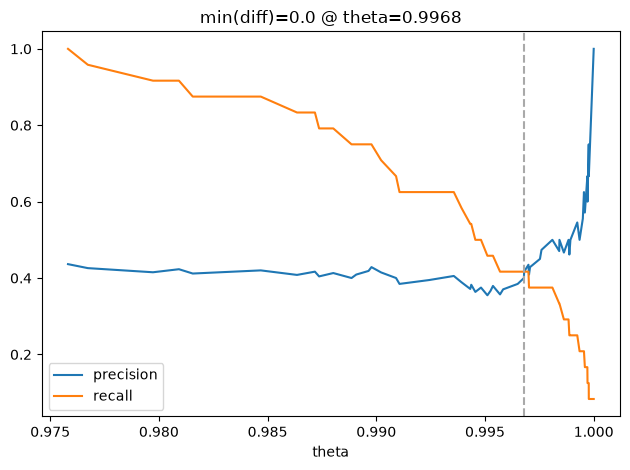

In [16]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, precision_recall_curve
import matplotlib.pyplot as plt

distances = 1 - np.array(calib_df['jaccard'])
relevances = calib_df['authorship']
precisions, recalls, thresholds = precision_recall_curve(relevances, distances, pos_label='S')
diffs = np.abs(precisions - recalls)
max_diff_idx = np.array(diffs).argmin()
max_diff = diffs[max_diff_idx]
max_diff_th = thresholds[max_diff_idx]
print(f'max(f1)={round(max_diff, 4)} @ theta={round(max_diff_th, 4)}')

plt.plot(thresholds, precisions[:-1], label='precision')
plt.plot(thresholds, recalls[:-1], label='recall')
plt.axvline(max_diff_th, ls='--', c='darkgrey')
plt.gca().set_xlabel('theta')
plt.gca().legend()
plt.title(f'min(diff)={round(max_diff, 4)} @ theta={round(max_diff_th, 4)}')
plt.tight_layout()

In [17]:
calib_thresh = 1 - max_diff_th
calib_thresh

np.float64(0.0032010397362151055)

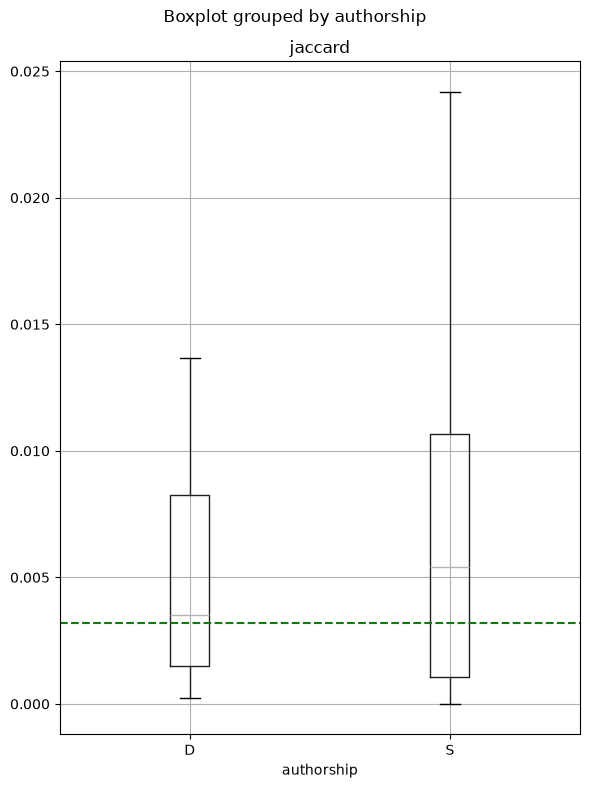

In [18]:
calib_df.boxplot('jaccard', 'authorship', figsize=(6, 8), showfliers=False)
plt.axhline(calib_thresh, c='green', ls='--')
plt.tight_layout();

1 represents identical texts, 0 represents completely different texts. A higher Jaccard coefficient denotes a higher similarity.
This plot shows that when two texts are written by the same author, they have a higher Jaccard coefficient,, i.e. they are more similair.

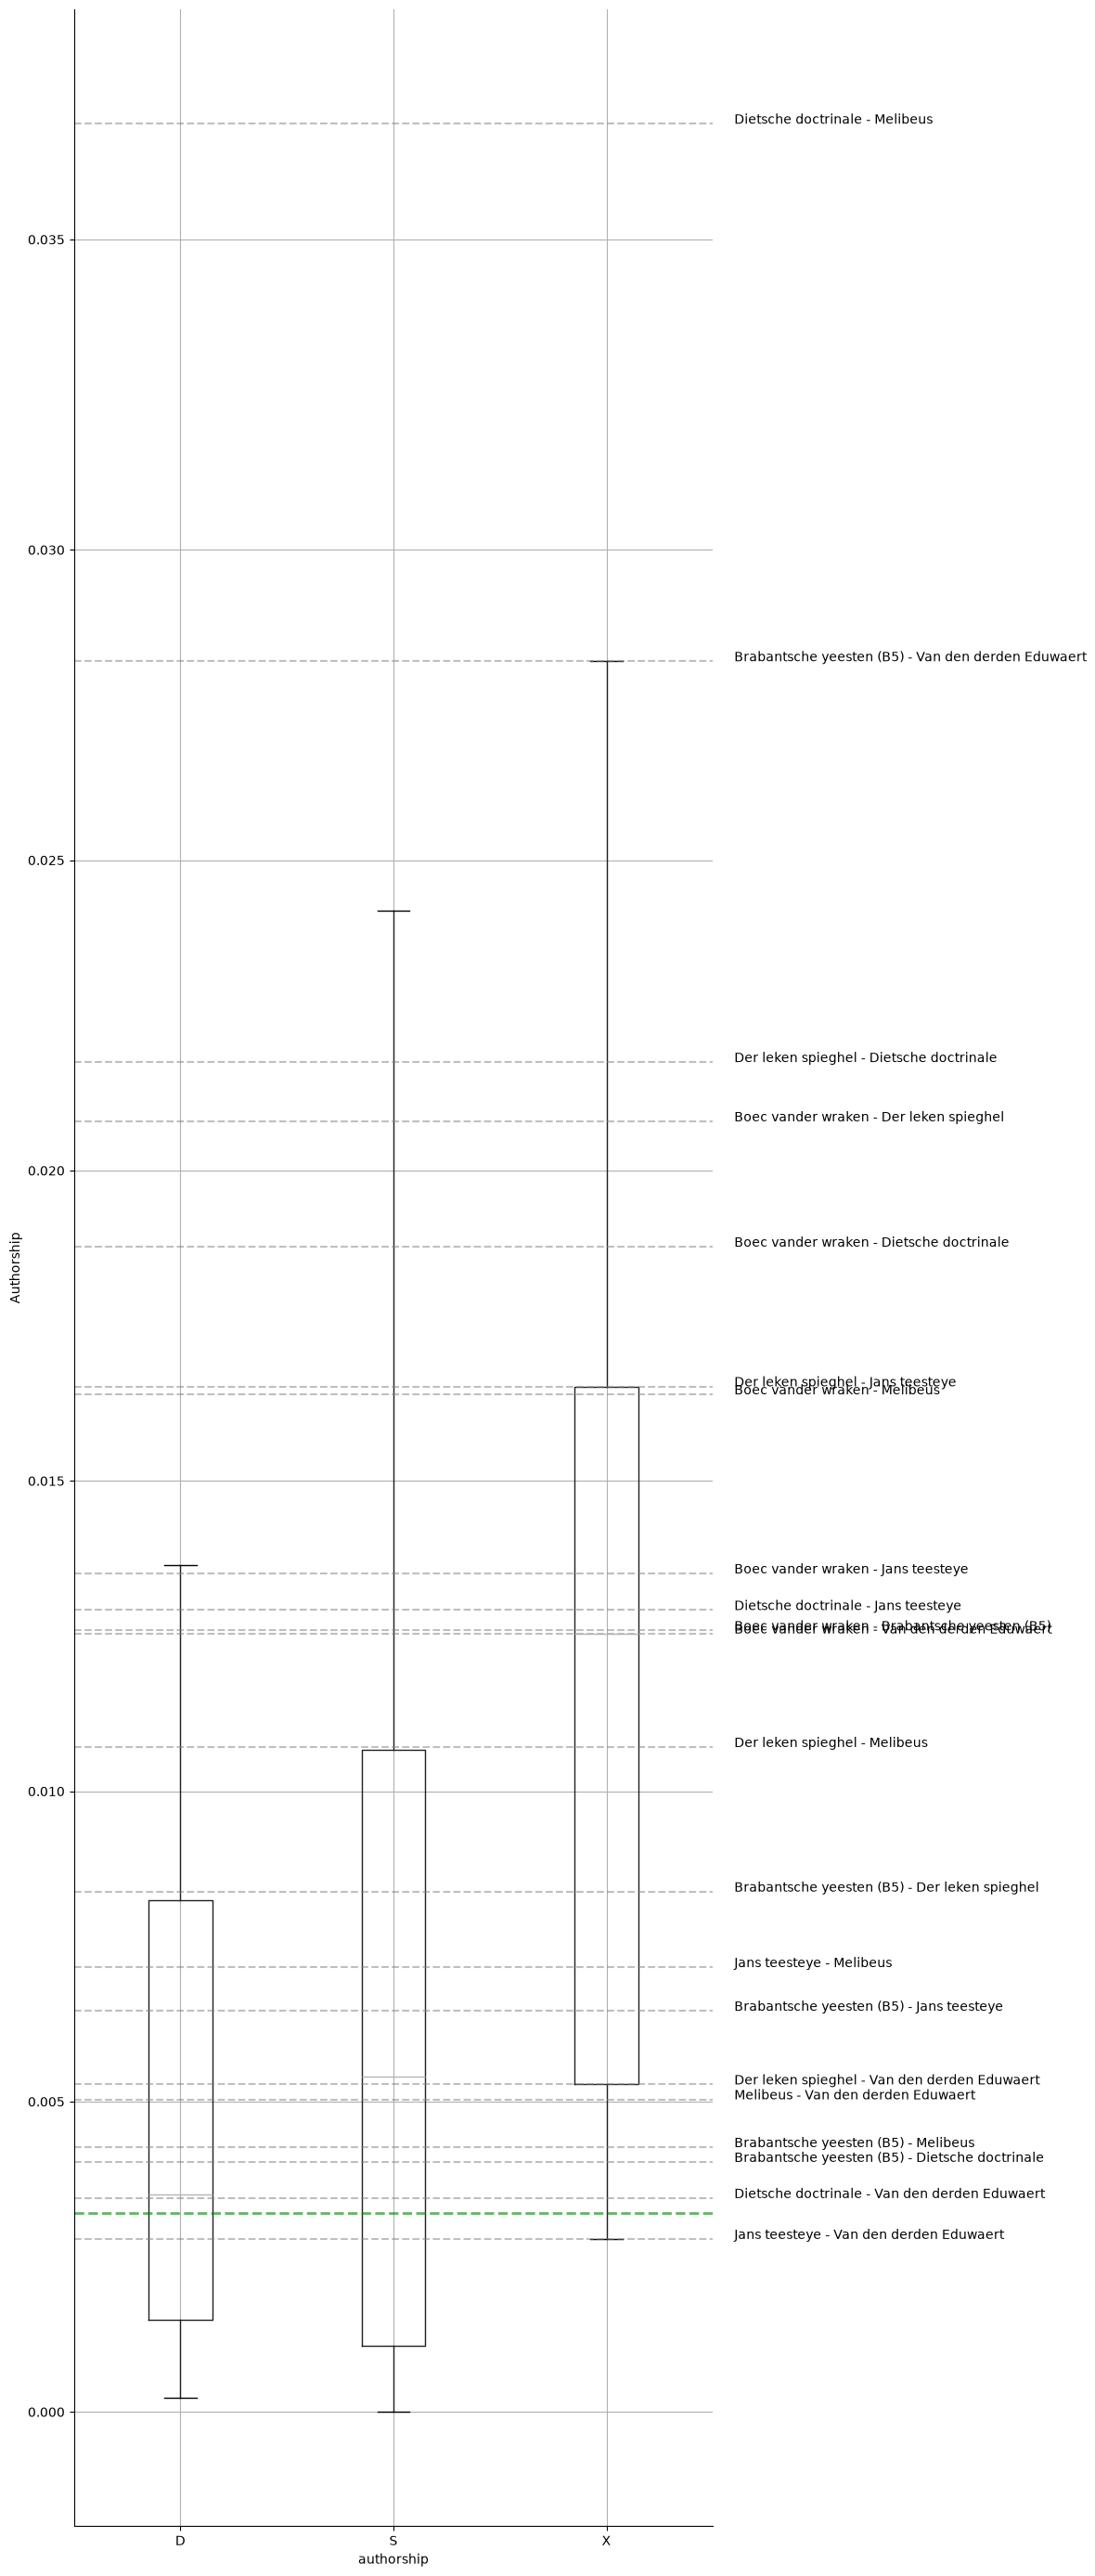

In [19]:
import seaborn as sb

distances = pd.concat([calib_df, trg_df])

distances.boxplot('jaccard', 'authorship', figsize=(12, 28), showfliers=False)
sb.despine()
plt.axhline(calib_thresh, c='green', linewidth=2, ls='--', alpha=.6)

for grouper, group in distances.groupby('authorship'):
    if grouper == 'X':
        for m, d in group.groupby(['t1', 't2'])['jaccard']:
            plt.gca().axhline(d.mean(), c='grey', ls='--', alpha=.5)
            plt.annotate(' - '.join(m), xy=[plt.gca().get_xlim()[1]+0.1, d.mean()],
                         annotation_clip=False)
            
plt.title('')
plt.ylabel('Jaccard Similarity')
plt.ylabel('Authorship')
plt.suptitle('')

plt.tight_layout();

## Szymkiewicz–Simpson

max(f1)=0.0 @ theta=0.9807


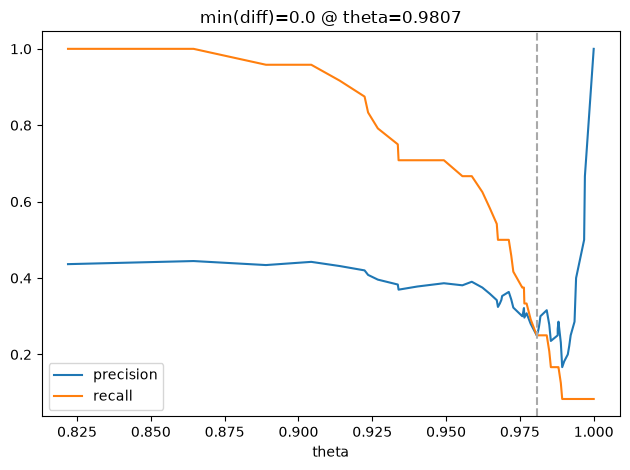

In [20]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, precision_recall_curve
import matplotlib.pyplot as plt

distances = 1 - np.array(calib_df['simpson'])
relevances = calib_df['authorship']
precisions, recalls, thresholds = precision_recall_curve(relevances, distances, pos_label='S')
diffs = np.abs(precisions - recalls)
max_diff_idx = np.array(diffs).argmin()
max_diff = diffs[max_diff_idx]
max_diff_th = thresholds[max_diff_idx]
print(f'max(f1)={round(max_diff, 4)} @ theta={round(max_diff_th, 4)}')

plt.plot(thresholds, precisions[:-1], label='precision')
plt.plot(thresholds, recalls[:-1], label='recall')
plt.axvline(max_diff_th, ls='--', c='darkgrey')
plt.gca().set_xlabel('theta')
plt.gca().legend()
plt.title(f'min(diff)={round(max_diff, 4)} @ theta={round(max_diff_th, 4)}')
plt.tight_layout()

In [21]:
calib_thresh = 1 - max_diff_th
calib_thresh

np.float64(0.019302708364506982)

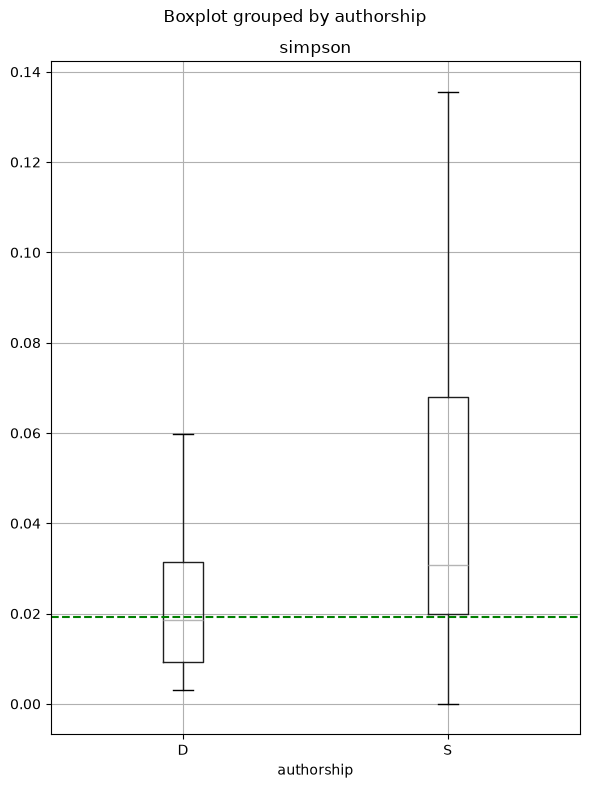

In [22]:
calib_df.boxplot('simpson', 'authorship', figsize=(6, 8), showfliers=False)
plt.axhline(calib_thresh, c='green', ls='--')
plt.tight_layout();

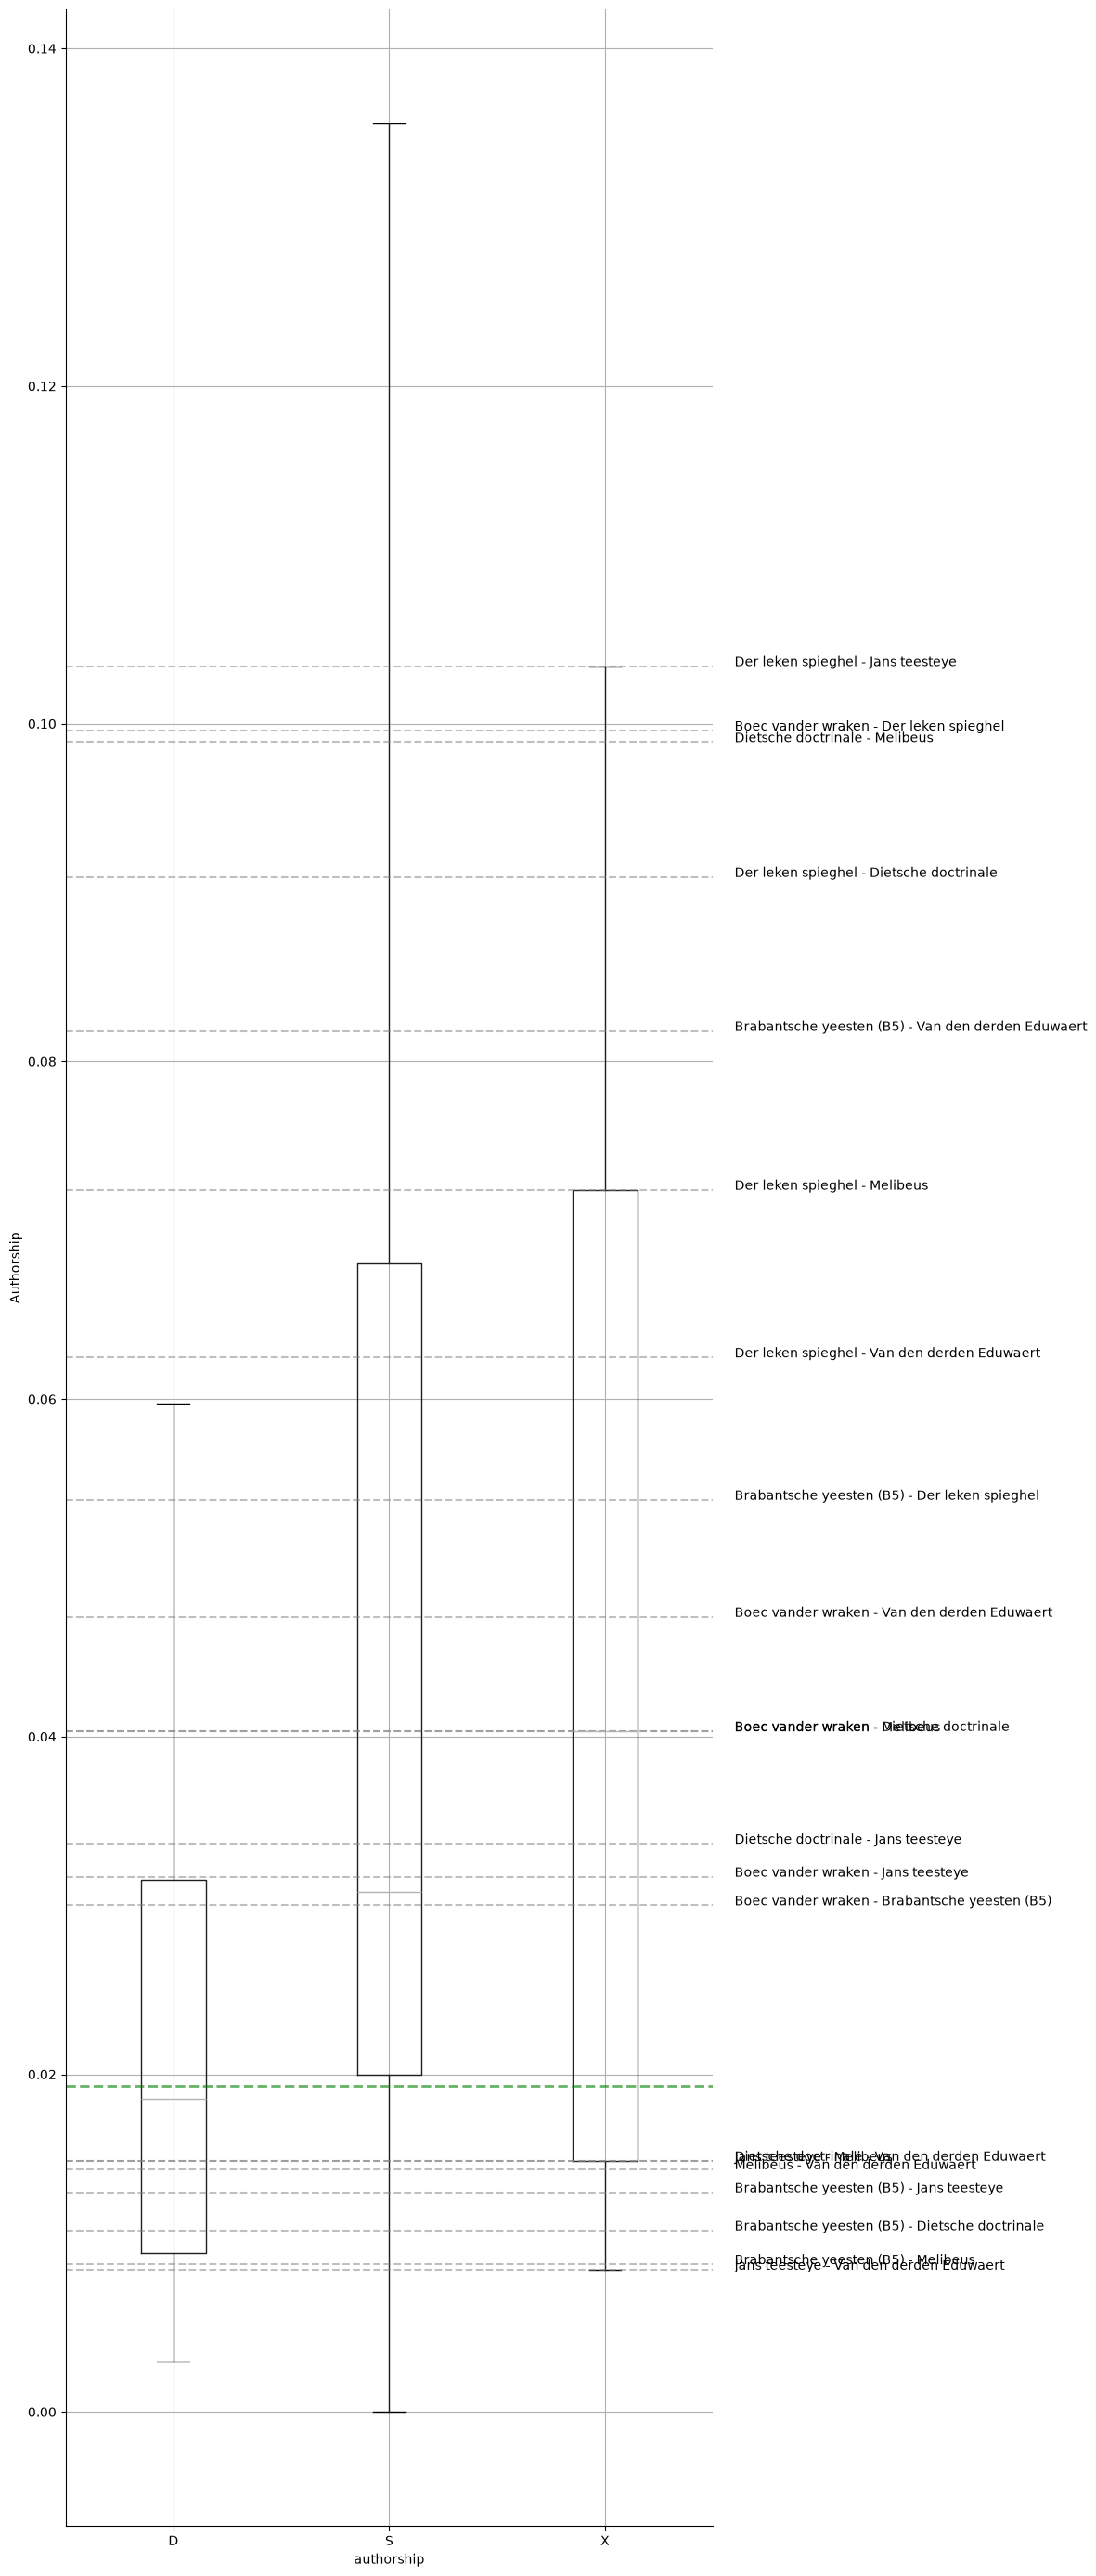

In [23]:
import seaborn as sb

distances = pd.concat([calib_df, trg_df])

distances.boxplot('simpson', 'authorship', figsize=(12, 28), showfliers=False)
sb.despine()
plt.axhline(calib_thresh, c='green', linewidth=2, ls='--', alpha=.6)

for grouper, group in distances.groupby('authorship'):
    if grouper == 'X':
        for m, d in group.groupby(['t1', 't2'])['simpson']:
            plt.gca().axhline(d.mean(), c='grey', ls='--', alpha=.5)
            plt.annotate(' - '.join(m), xy=[plt.gca().get_xlim()[1]+0.1, d.mean()],
                         annotation_clip=False)
            
plt.title('')
plt.ylabel('Szymkiewicz–Simpson index')
plt.ylabel('Authorship')
plt.suptitle('')

plt.tight_layout();

## Sørensen–Dice

max(f1)=0.0 @ theta=0.9936


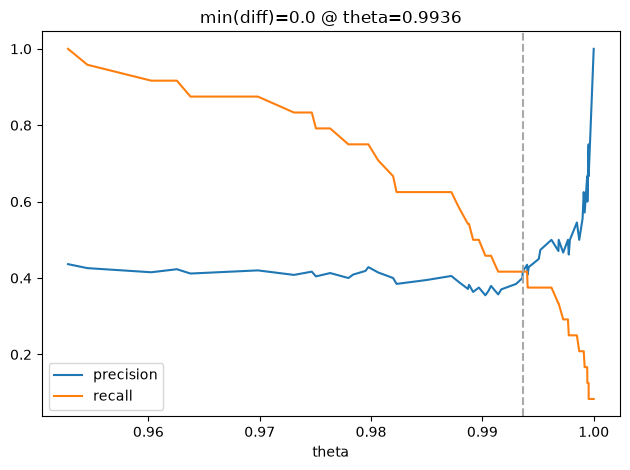

In [24]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, precision_recall_curve
import matplotlib.pyplot as plt

distances = 1 - np.array(calib_df['dice'])
relevances = calib_df['authorship']
precisions, recalls, thresholds = precision_recall_curve(relevances, distances, pos_label='S')
diffs = np.abs(precisions - recalls)
max_diff_idx = np.array(diffs).argmin()
max_diff = diffs[max_diff_idx]
max_diff_th = thresholds[max_diff_idx]
print(f'max(f1)={round(max_diff, 4)} @ theta={round(max_diff_th, 4)}')

plt.plot(thresholds, precisions[:-1], label='precision')
plt.plot(thresholds, recalls[:-1], label='recall')
plt.axvline(max_diff_th, ls='--', c='darkgrey')
plt.gca().set_xlabel('theta')
plt.gca().legend()
plt.title(f'min(diff)={round(max_diff, 4)} @ theta={round(max_diff_th, 4)}')
plt.tight_layout()

In [25]:
calib_thresh = 1 - max_diff_th
calib_thresh

np.float64(0.006381651552228806)

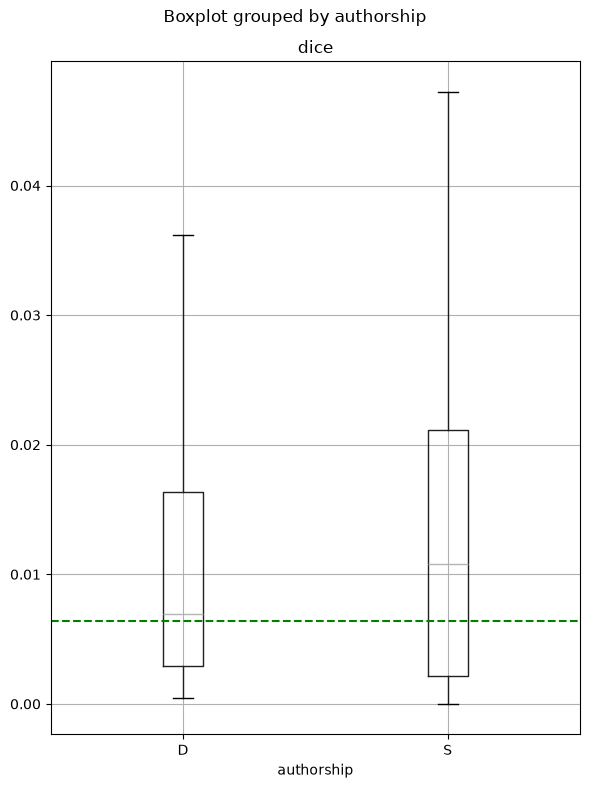

In [26]:
calib_df.boxplot('dice', 'authorship', figsize=(6, 8), showfliers=False)
plt.axhline(calib_thresh, c='green', ls='--')
plt.tight_layout();

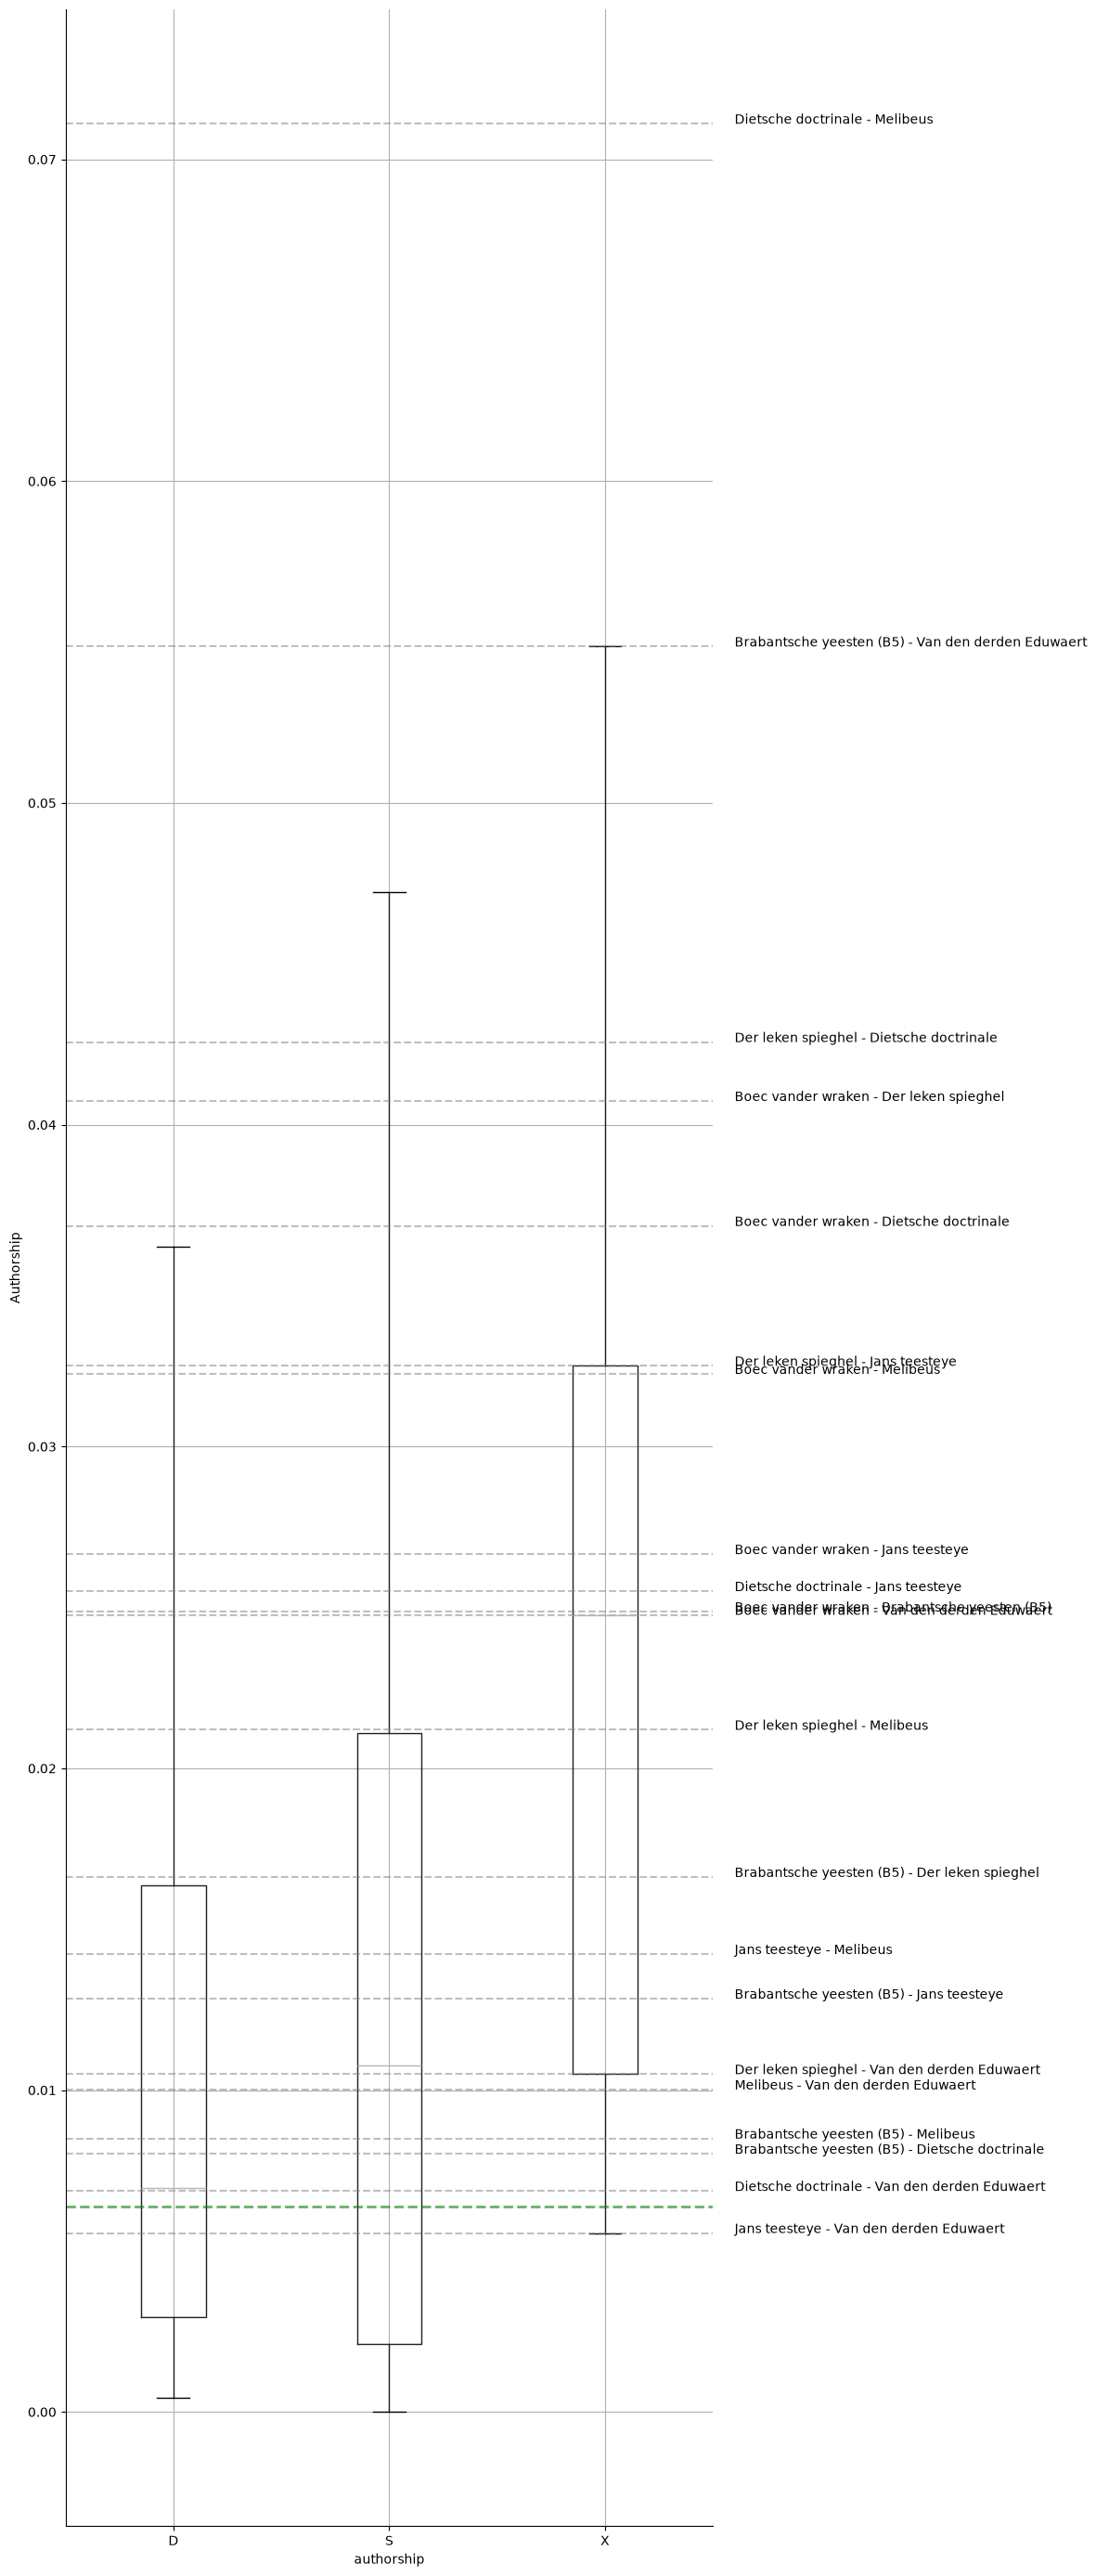

In [27]:
import seaborn as sb

distances = pd.concat([calib_df, trg_df])

distances.boxplot('dice', 'authorship', figsize=(12, 28), showfliers=False)
sb.despine()
plt.axhline(calib_thresh, c='green', linewidth=2, ls='--', alpha=.6)

for grouper, group in distances.groupby('authorship'):
    if grouper == 'X':
        for m, d in group.groupby(['t1', 't2'])['dice']:
            plt.gca().axhline(d.mean(), c='grey', ls='--', alpha=.5)
            plt.annotate(' - '.join(m), xy=[plt.gca().get_xlim()[1]+0.1, d.mean()],
                         annotation_clip=False)
            
plt.title('')
plt.ylabel('Sørensen–Dice index')
plt.ylabel('Authorship')
plt.suptitle('')

plt.tight_layout();

Szymkiewicz–Simpson is best in differentiating between SA and DA pairs, this seems to be the most interesting method for us.

## Casy study: Boec exemplaer

We can look at each of the distance metrics and see which texts have the most phrases in common.

In [28]:
# Subslice of the big dataframe with only Boec Exemplaer, the focus text in this example

BE = jaccard_df[(jaccard_df['t1'] == 'Boec Exemplaer') | (jaccard_df['t2'] == 'Boec Exemplaer')]
BE

,t1,t2,parallel_verses,author_t1,author_t2,subgenre_t1,subgenre_t2,verse_count_t1,verse_count_t2,union,jaccard,min_verses,simpson,dice
1651,Boec Exemplaer,Melibeus,16,NaN,NaN,Didactiek,Didactiek,297,3771,4052,0.003949,297,0.053872,0.007866
1613,Boec Exemplaer,Expositie vanden viere vingheren ende vanden dume,2,NaN,NaN,Didactiek,Didactiek,297,218,513,0.003899,218,0.009174,0.007767
1609,Boec Exemplaer,Dietsche doctrinale,16,NaN,NaN,Didactiek,Didactiek,297,6720,7001,0.002285,297,0.053872,0.004560
809,Barlaam en Josaphat,Boec Exemplaer,1,NaN,NaN,Ridder,Didactiek,177,297,473,0.002114,177,0.005650,0.004219
332,Anatomie van de mens,Boec Exemplaer,1,NaN,NaN,Didactiek,Didactiek,180,297,476,0.002101,180,0.005556,0.004193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1614,Boec Exemplaer,Ferguut,0,NaN,NaN,Didactiek,Arthur,297,5602,5899,0.000000,297,0.000000,0.000000
1590,Boec Exemplaer,Borchgravinne van Vergi (2),0,NaN,NaN,Didactiek,Ridder,297,484,781,0.000000,297,0.000000,0.000000
1587,Boec Exemplaer,Boeve van Hamtone,0,NaN,NaN,Didactiek,Karel,297,113,410,0.000000,113,0.000000,0.000000
1585,Boec Exemplaer,Boec van den houte,0,NaN,NaN,Didactiek,Religie,297,849,1146,0.000000,297,0.000000,0.000000


In [29]:
BE.sort_values(by="simpson", ascending=False).head(10)

,t1,t2,parallel_verses,author_t1,author_t2,subgenre_t1,subgenre_t2,verse_count_t1,verse_count_t2,union,jaccard,min_verses,simpson,dice
13540,Boec Exemplaer,Der leken spieghel,25,NaN,Jan van Boendale,Didactiek,Didactiek,297,21987,22259,0.001123,297,0.084175,0.002244
1705,Boec Exemplaer,Spiegel historiael (P1-P4),24,NaN,Jacob van Maerlant,Didactiek,Historiografie,297,88713,88986,0.000270,297,0.080808,0.000539
1651,Boec Exemplaer,Melibeus,16,NaN,NaN,Didactiek,Didactiek,297,3771,4052,0.003949,297,0.053872,0.007866
1609,Boec Exemplaer,Dietsche doctrinale,16,NaN,NaN,Didactiek,Didactiek,297,6720,7001,0.002285,297,0.053872,0.004560
1642,Boec Exemplaer,Lancelot,15,NaN,NaN,Didactiek,Arthur,297,37317,37599,0.000399,297,0.050505,0.000798
1586,Boec Exemplaer,Boec vander wraken,12,NaN,Jan van Boendale,Didactiek,Didactiek,297,5653,5938,0.002021,297,0.040404,0.004034
1706,Boec Exemplaer,Spiegel historiael (P2),12,NaN,Philip Utenbroeke,Didactiek,Historiografie,297,35006,35291,0.000340,297,0.040404,0.000680
1633,Boec Exemplaer,Historie van Troyen,11,NaN,Jacob van Maerlant,Didactiek,Ridder,297,37582,37868,0.000290,297,0.037037,0.000581
492,Arturs doet,Boec Exemplaer,9,NaN,NaN,Arthur,Didactiek,13024,297,13312,0.000676,297,0.030303,0.001351
1709,Boec Exemplaer,Spieghel der menscheliker behoudenesse,9,NaN,NaN,Didactiek,Didactiek,297,14486,14774,0.000609,297,0.030303,0.001218


## Antwerp School vs. Corpus Middle Dutch

We now create a function which creates a boxplot to compare the distance metrics between a text and the Antwerp School and the text with a chosen control corpus. The control corpus are texts in the same subgenre. A Mann–Whitney U test is included to see whether the difference in distance is significant.

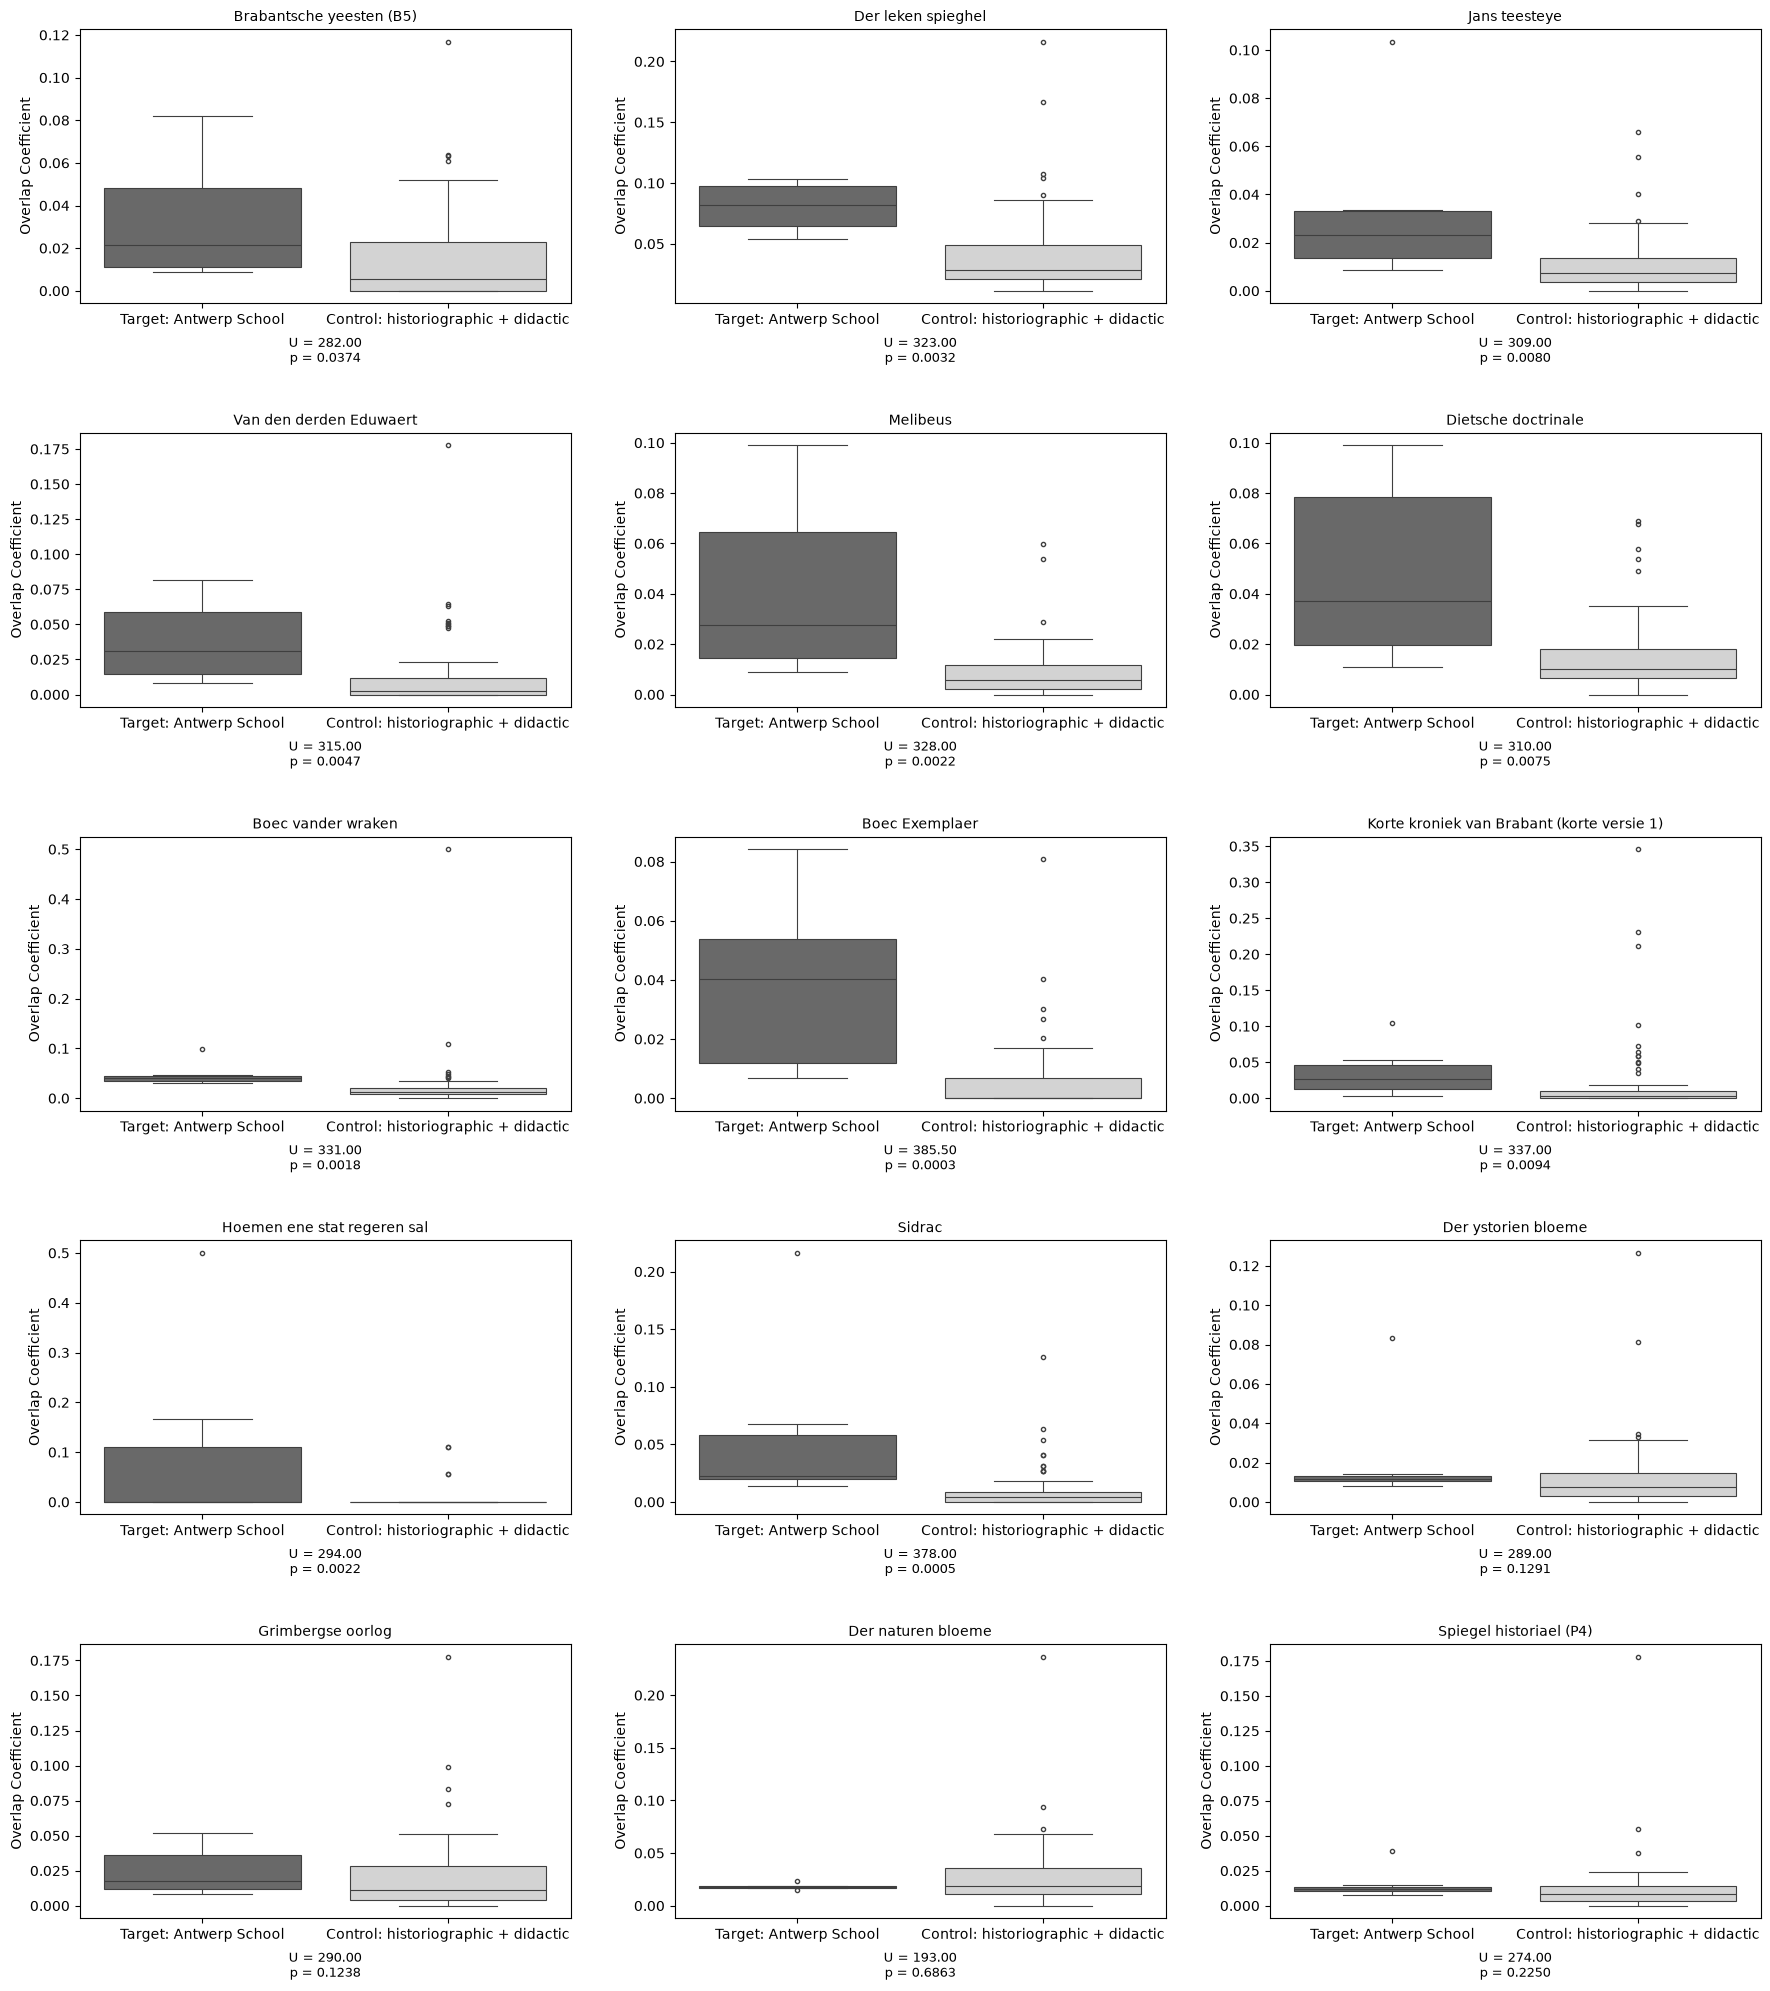

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

# define the target corpus: Antwerp School
target_titles = [
    'Brabantsche yeesten (B5)',
    'Der leken spieghel',
    'Jans teesteye',
    'Van den derden Eduwaert',
    'Melibeus',
    'Dietsche doctrinale',
    'Boec vander wraken',
    #'Boec Exemplaer',
    #'Korte kroniek van Brabant (korte versie 1)',
    #'Sidrac',
    #'Hoemen ene stat regeren sal'
]

# define the different control corpus (if not "all"):
control_subgenres = ['Didactiek', 'Historiografie']


def plot_similarity_on_ax(jaccard_df, focus_title, ax, control_type="all", metric="simpson"):
    """
    Same logic as your original function,
    but plots on a provided matplotlib axis (ax)
    and writes Mann–Whitney results under the subplot.
    """

    # subset df of focus title
    df = jaccard_df[(jaccard_df['t1'] == focus_title) | (jaccard_df['t2'] == focus_title)].copy()

    # extract metadata from the "other" text
    def get_metadata(row):
        if row['t1'] == focus_title:
            return row['t2'], row['author_t2'], row['subgenre_t2']
        elif row['t2'] == focus_title:
            return row['t1'], row['author_t1'], row['subgenre_t1']
        else:
            return None, None, None

    df[['other_title', 'other_author', 'other_subgenre']] = df.apply(
        lambda row: pd.Series(get_metadata(row)), axis=1
    )

    # make sure focus_title is not inside target_titles
    effective_targets = [t for t in target_titles if t != focus_title]

    # assign groups
    def assign_group(row):
        if row['other_title'] in effective_targets:
            return 'Target: Antwerp School'
        if control_type == "all":
            return 'Control: all'
        if control_type == "subgenres" and row['other_subgenre'] in control_subgenres:
            return 'Control: historiographic + didactic'
        return None

    df['group'] = df.apply(assign_group, axis=1)
    filtered_df = df[df['group'].notnull()]

    if metric not in filtered_df.columns:
        raise ValueError(f"Metric '{metric}' not found in dataframe.")

    # ensure consistent order
    target_label = 'Target: Antwerp School'
    control_labels = [g for g in filtered_df['group'].unique() if g.startswith('Control')]
    if len(control_labels) == 0:
        ax.set_title(f"{focus_title}\nNo control data")
        return

    control_label = control_labels[0]
    order = [target_label, control_label]

    # plot on given axis
    sns.boxplot(
        x='group',
        y=metric,
        hue='group',
        data=filtered_df,
        order=order,
        palette={
            'Target: Antwerp School': 'dimgray',
            control_label: 'lightgrey'
        },
        linewidth=0.8,
        fliersize=3,
        ax=ax
    )

    ax.set_title(focus_title, fontsize=10)
    #ax.set_ylabel(metric.capitalize())
    ax.set_ylabel('Overlap Coefficient')
    ax.set_xlabel('')

    # Mann–Whitney U test
    target_scores = filtered_df[filtered_df['group'].str.startswith('Target')][metric]
    control_scores = filtered_df[filtered_df['group'].str.startswith('Control')][metric]

    if len(target_scores) > 0 and len(control_scores) > 0:
        u_stat, p_val = mannwhitneyu(target_scores, control_scores, alternative='two-sided')

        text = f"U = {u_stat:.2f}\np = {p_val:.4f}"

        # place text below plot
        ax.text(
            0.5, -0.12,
            text,
            transform=ax.transAxes,
            ha='center',
            va='top',
            fontsize=9
        )
    else:
        ax.text(
            0.5, -0.12,
            "Not enough data",
            transform=ax.transAxes,
            ha='center',
            va='top',
            fontsize=9
        )

cases = [
    'Brabantsche yeesten (B5)',
    'Der leken spieghel',
    'Jans teesteye',
    'Van den derden Eduwaert',
    'Melibeus',
    'Dietsche doctrinale',
    'Boec vander wraken',
    'Boec Exemplaer',
    'Korte kroniek van Brabant (korte versie 1)',
    'Hoemen ene stat regeren sal',
    'Sidrac',
    'Der ystorien bloeme',
    'Grimbergse oorlog',
    'Der naturen bloeme',
    'Spiegel historiael (P4)'
]

fig, axes = plt.subplots(5, 3, figsize=(18, 20))
axes = axes.flatten()

for i, title in enumerate(cases):
    plot_similarity_on_ax(
        jaccard_df,
        focus_title=title,
        ax=axes[i],
        control_type="subgenres",
        metric="simpson"
    )

plt.tight_layout(h_pad=3.5)

plt.savefig("../figures/simpson_similarity_grid.png", dpi=300, bbox_inches="tight")

plt.show()

## Summary boxplot

I compared all works of the Antwerp School exhaistively to each other and saved the Simpson similarity.
I compared all works of the Antwerp School to all other historiographic and didactic works on Corpus Middle Dutch and save the Simpson similarity.

The result of this is shown below in the boxplot. The Antwerp School texts show a tight intertextual network compared to other works of the same (sub)genre.

In [31]:
# include the short titles now
target_titles = [
    'Brabantsche yeesten (B5)',
    'Der leken spieghel',
    'Jans teesteye',
    'Van den derden Eduwaert',
    'Melibeus',
    'Dietsche doctrinale',
    'Boec vander wraken',
    'Boec Exemplaer',
    'Korte kroniek van Brabant (korte versie 1)',
    'Sidrac',
    'Hoemen ene stat regeren sal'
]

In [32]:
subgenres_keep = ["Didactiek", "Historiografie"]

genre = jaccard_df[
    jaccard_df["subgenre_t1"].isin(subgenres_keep) &
    jaccard_df["subgenre_t2"].isin(subgenres_keep)
].copy()

In [33]:
summary_target = []
summary_control = []

for _, row in genre.iterrows():
    if row['t1'] in target_titles and row['t2'] in target_titles:
        summary_target.append(row['simpson'])
    if row['t1'] in target_titles or row['t2'] in target_titles:
        summary_control.append(row['simpson'])

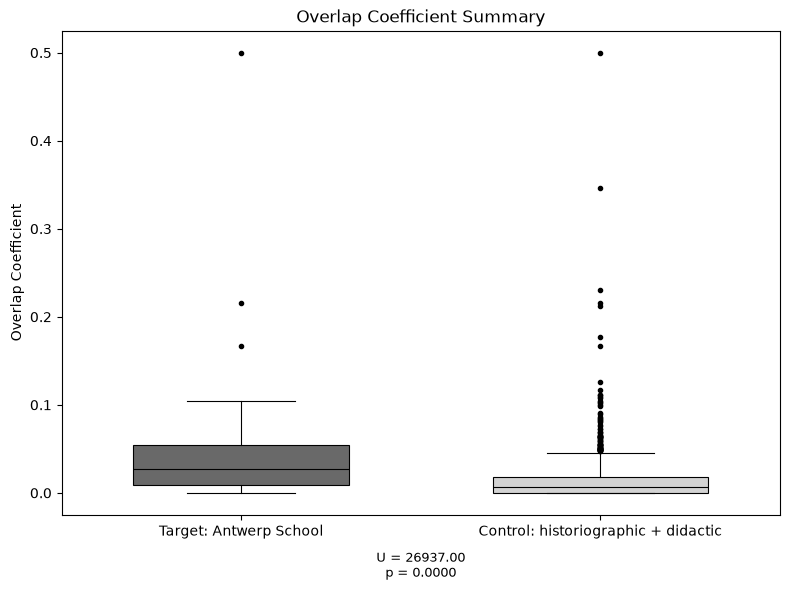

In [36]:
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6))

bp = ax.boxplot(
    [summary_target, summary_control],
    tick_labels=['Target: Antwerp School', 'Control: historiographic + didactic'],
    patch_artist=True,
    widths=0.6,
    boxprops=dict(linewidth=0.8, color='black'),
    whiskerprops=dict(linewidth=0.8, color='black'),
    capprops=dict(linewidth=0.8, color='black'),
    medianprops=dict(linewidth=0.8, color='black'),
    flierprops=dict(marker='o', markersize=3, markerfacecolor='black',
                    markeredgecolor='black', linestyle='none')
)

# colours
for patch, color in zip(bp['boxes'], ['dimgray', 'lightgrey']):
    patch.set_facecolor(color)

ax.set_title('Overlap Coefficient Summary')
ax.set_ylabel('Overlap Coefficient')

# Mann–Whitney U test
if len(summary_target) > 0 and len(summary_control) > 0:
    u_stat, p_val = mannwhitneyu(summary_target, summary_control, alternative='two-sided')
    text = f"U = {u_stat:.2f}\np = {p_val:.4f}"
else:
    text = "Not enough data"

# place text just below the lowest box in data coordinates
y_min = min(np.min(summary_target), np.min(summary_control))
ax.text(
    1.5,
    y_min - 0.12*(ax.get_ylim()[1]-ax.get_ylim()[0]),
    text,
    ha='center',
    va='top',
    fontsize=9
)

plt.tight_layout()

plt.savefig("../figures/simpson_similarity_summary.png", dpi=300, bbox_inches="tight")

plt.show()

## Network

In [35]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

target_titles = [
    'Brabantsche yeesten (B5)',
    'Korte kroniek van Brabant (korte versie 1)',
    'Der leken spieghel',
    'Jans teesteye',
    'Van den derden Eduwaert',
    'Melibeus',
    'Boec Exemplaer',
    'Dietsche doctrinale',
    'Boec vander wraken',
    'Sidrac',
    'Hoemen ene stat regeren sal'
]

def plot_similarity_network(jaccard_df, target_titles, weight_col="simpson", min_weight=0.0):

    # graph
    G = nx.Graph()

    for _, row in jaccard_df.iterrows():
        t1 = row["t1"]
        t2 = row["t2"]
        w  = row[weight_col]

        if pd.notna(w) and w >= min_weight:
            G.add_edge(t1, t2, weight=w)

    # layout
    pos = nx.forceatlas2_layout(
        G,
        seed=0,
        weight="weight",
    )

    # node colour
    node_colors = ["steelblue" if node in target_titles else "lightsteelblue" for node in G.nodes()]

    #edge weights
    weights = [G[u][v]["weight"] for u, v in G.edges()]
    edge_widths = [w * 1.5 for w in weights]

    # labels
    labels = {}
    label_bboxes = {}
    for node in G.nodes():
        labels[node] = node
        if node in target_titles:
            label_bboxes[node] = dict(facecolor='lightgrey', edgecolor='grey', boxstyle='round,pad=0.2', linewidth=0.5)
        else:
            label_bboxes[node] = dict(facecolor='white', edgecolor='grey', boxstyle='round,pad=0.2', linewidth=0.5)

    plt.figure(figsize=(12, 10))

    nx.draw_networkx_nodes(G, pos, node_color=node_colors)
    nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.6)

    # offset for labels
    y_offset = 0.02  # adjust as needed (in data coordinates)
    
    # draw labels individually with bbox
    for node, (x, y) in pos.items():
        plt.text(
            x, y + y_offset,      # shift label slightly upward
            node,
            fontsize=6,           
            ha='center', va='center',
            bbox=dict(
                facecolor='lightgrey' if node in target_titles else 'white',
                edgecolor='grey',
                boxstyle='square,pad=0.2',
                linewidth=0.5
            )
        )

    plt.title(f"Text Similarity Network ({weight_col.capitalize()})")
    plt.axis("off")
    plt.tight_layout()

    plt.savefig("../figures/similarity_network.png", dpi=300, bbox_inches="tight")
    
    plt.show()

    return G

In [36]:
subgenres_keep = ["Didactiek", "Historiografie"]

genre = jaccard_df[
    jaccard_df["subgenre_t1"].isin(subgenres_keep) &
    jaccard_df["subgenre_t2"].isin(subgenres_keep)
].copy()

Nodes: 58 | Edges: 142


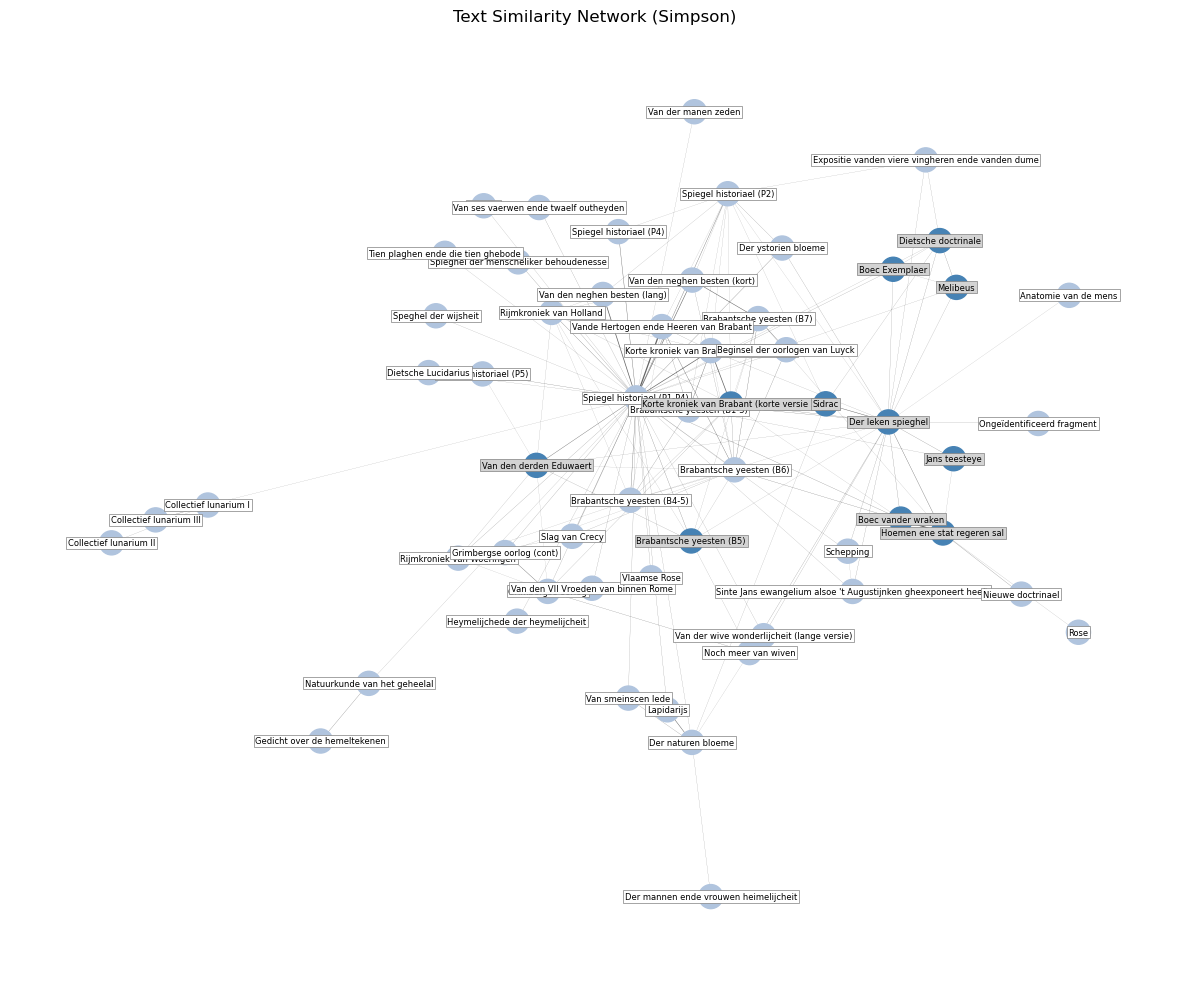

In [37]:
G = plot_similarity_network(
    genre,
    target_titles=target_titles,
    weight_col="simpson",
    min_weight=0.05
)